In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score, accuracy_score, ConfusionMatrixDisplay

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/diabetes_prediction_dataset.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
df.shape

(100000, 9)

In [5]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [6]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


<Axes: xlabel='diabetes'>

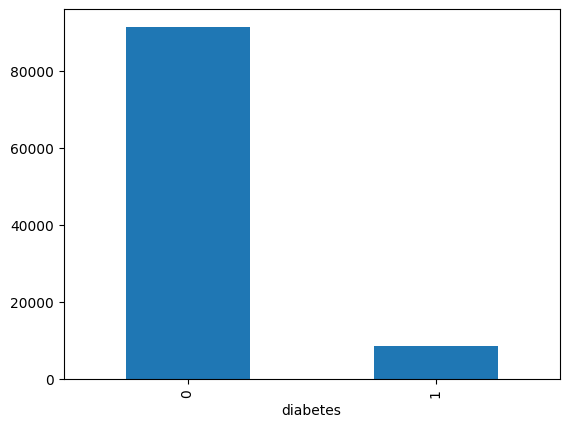

In [7]:
df["diabetes"].value_counts().plot(kind="bar")

In [8]:
X = df.drop(columns=["diabetes"])
y = df["diabetes"]

In [9]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(x_train.shape)

(80000, 8)


In [10]:
cat_col = x_train.select_dtypes("object").columns.tolist()

for col in cat_col:
    enc = LabelEncoder()
    x_train[col] = enc.fit_transform(x_train[col])
    x_test[col] = enc.transform(x_test[col])

In [11]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [12]:
svm = SVC(kernel="rbf", probability=True, random_state=42)
svm.fit(x_train, y_train)

y_pred_svm = svm.predict(x_test)
y_proba_svm = svm.predict_proba(x_test)[:, 1]

In [13]:
gnb = GaussianNB()
gnb.fit(x_train, y_train)

y_pred_gnb = gnb.predict(x_test)
y_proba_gnb = gnb.predict_proba(x_test)[:, 1]

In [14]:
print("SVM Classification Report")

print(classification_report(y_test, y_pred_svm, digits=4))

SVM Classification Report
              precision    recall  f1-score   support

           0     0.9641    0.9984    0.9809     18300
           1     0.9723    0.5994    0.7416      1700

    accuracy                         0.9645     20000
   macro avg     0.9682    0.7989    0.8613     20000
weighted avg     0.9648    0.9645    0.9606     20000



In [15]:
print("Naive Bayes Classification Report")

print(classification_report(y_test, y_pred_gnb, digits=4))

Naive Bayes Classification Report
              precision    recall  f1-score   support

           0     0.9670    0.9273    0.9467     18300
           1     0.4574    0.6594    0.5401      1700

    accuracy                         0.9045     20000
   macro avg     0.7122    0.7934    0.7434     20000
weighted avg     0.9237    0.9045    0.9122     20000



In [16]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_proba_gnb)

auc_score_gnb = roc_auc_score(y_test, y_proba_gnb)
auc_score_svm = roc_auc_score(y_test, y_proba_svm)

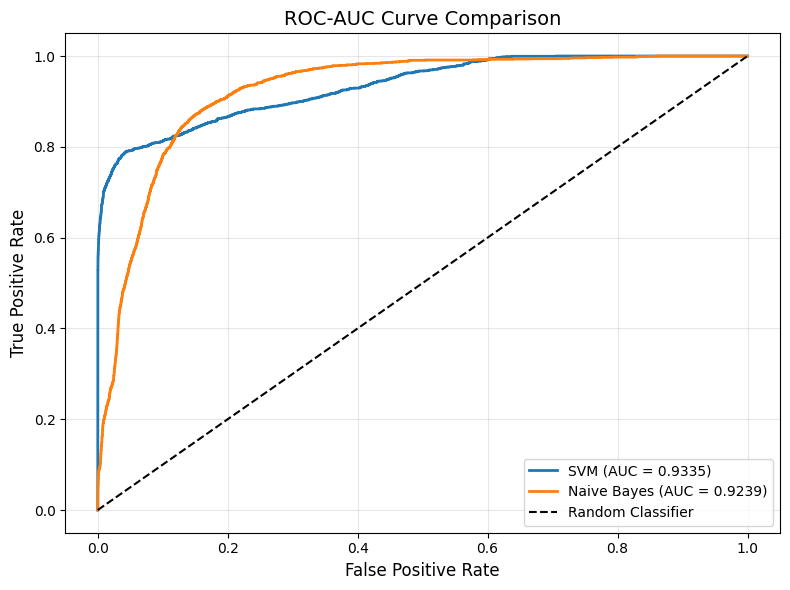

In [17]:
plt.figure(figsize=(8, 6))

plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_score_svm:.4f})', linewidth=2)
plt.plot(fpr_gnb, tpr_gnb, label=f'Naive Bayes (AUC = {auc_score_gnb:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-AUC Curve Comparison', fontsize=14)

plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

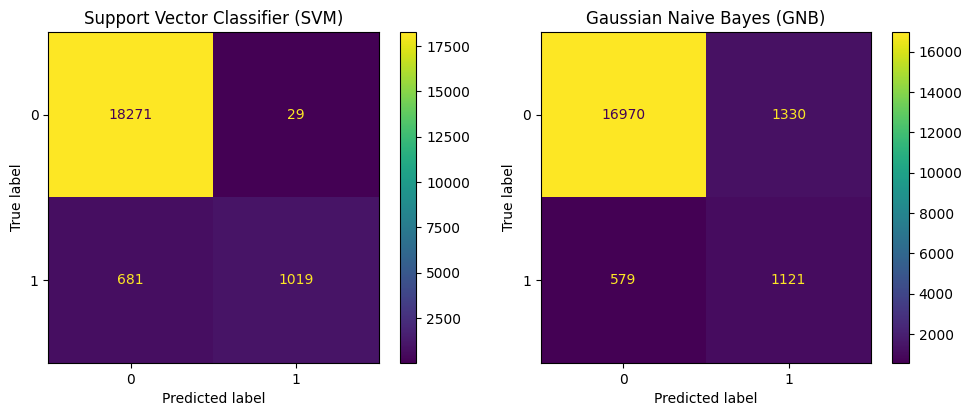

In [18]:
model_preds = {
    "Support Vector Classifier (SVM)": y_pred_svm,
    "Gaussian Naive Bayes (GNB)": y_pred_gnb,
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, y_pred) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    ax.grid(False)

    ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [19]:
results = pd.DataFrame({
    'Model': ['SVM (RBF)', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_gnb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_gnb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_gnb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_gnb)
    ],
    'ROC-AUC': [auc_score_svm, auc_score_gnb]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM (RBF),0.96450,0.972328,0.599412,0.741630,0.933484
1,Naive Bayes,0.90455,0.457364,0.659412,0.540111,0.923918
